## 1. What this notebook computes

A Kohn-Sham state of dirac16complex carries energy and momentum. The
**energy-momentum tensor** of the state has four different diagonal components: the
energy density $\rho$ and the pressures $p_3$ (along 3-space), $p_t$ (along the
three extra times) and $p_8$ (along the hidden direction). They depend on the
hidden coordinate $y$. This notebook

- runs the Rust Kohn-Sham solver for two states and checks that the profiles it
  writes are those of the committed Revision record;
- draws the four components, as proper densities and as the densities that are
  integrated over $y$;
- checks the **conservation law along the hidden direction**,
  $(e^{6Hy} p_8)' = 3H e^{6Hy}(p_3 + p_t)$, point by point and integrated;
- integrates the energy density to the total Kohn-Sham energy;
- solves the state $N = 136$ at 17 slices of the deflating history and checks the
  **energy-change identity**
  $dE/da_4 = -3 \cdot 2\,\mathrm{Vol}_7 \int e^{6Hy}(p_3 - p_t)\,dy$: the energy of
  the gas changes only through the difference between the 3-space pressure and the
  extra-time pressure;
- shows how the interaction adds the same energy density to $p_3$, $p_t$ and $p_8$;
- tests, on its own numbers, the three conditions that a source of the equations
  for $a_4$ must meet, and reproduces the Revision record that shows they fail.

It draws seven figures and takes about half a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 15b (Energy-momentum profiles and the conservation law along the hidden
direction) is the file `Revision/textbook/notebooks/15b_emt_profiles.ipynb` of the
repository Dirac_claude. It runs the Rust Kohn-Sham solver for chosen states of the
Kohn-Sham gas of dirac16complex, reads the profiles of the energy density and of the
three pressures along the hidden coordinate, checks them against the committed Revision
record, verifies the conservation law of the energy-momentum tensor along the hidden
direction point by point and integrated, integrates the profiles to the total energy, and
checks the energy-change identity dE/da4 = minus three times the integrated difference of
the 3-space and extra-time pressures along the deflating history. It also tests, on its
own numbers, the three conditions that a source of the equations for a4 must meet, and
reproduces the Revision record that shows that the Kohn-Sham states fail them (the
history is a prescribed background). Before it runs the solver, the notebook builds it
with cargo (a full build of about a minute when the program is missing, a second when it
is up to date). The solver writes its output files (about 1 MB) into the folder
`Revision/kohn_sham/solver/target/textbook_15b`, which git ignores. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
run Jupyter, the program that shows and runs notebooks. It also needs Rust (the program
cargo, version 1.91.1 or newer), because it runs the Rust program revision_ks_solver,
which is part of the repository and is built on your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/kohn_sham/solver/target/release/revision_ks_solver` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 15b_emt_profiles.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 25 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 15b_emt_profiles.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
15b_emt_profiles.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/15b.captions.json`
- `Revision/textbook/figures/15b_1_proper_emt.png`
- `Revision/textbook/figures/15b_2_coordinate_emt.png`
- `Revision/textbook/figures/15b_3_y_conservation.png`
- `Revision/textbook/figures/15b_4_energy_slopes.png`
- `Revision/textbook/figures/15b_5_integrated_ratios.png`
- `Revision/textbook/figures/15b_6_energy_spreading.png`
- `Revision/textbook/figures/15b_7_interaction_terms.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 18 CHECKS PASSED (notebook 15b)

and the notebook must show 7 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/15b_emt_profiles.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 15b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 15b (Energy-momentum profiles and the conservation law along the hidden
# direction) is the file Revision/textbook/notebooks/15b_emt_profiles.ipynb of the
# repository Dirac_claude. It runs the Rust Kohn-Sham solver for chosen states of the
# Kohn-Sham gas of dirac16complex, reads the profiles of the energy density and of the
# three pressures along the hidden coordinate, checks them against the committed Revision
# record, verifies the conservation law of the energy-momentum tensor along the hidden
# direction point by point and integrated, integrates the profiles to the total energy,
# and checks the energy-change identity dE/da4 = minus three times the integrated
# difference of the 3-space and extra-time pressures along the deflating history. It also
# tests, on its own numbers, the three conditions that a source of the equations for a4
# must meet, and reproduces the Revision record that shows that the Kohn-Sham states fail
# them (the history is a prescribed background). Before it runs the solver, the notebook
# builds it with cargo (a full build of about a minute when the program is missing, a
# second when it is up to date). The solver writes its output files (about 1 MB) into the
# folder Revision/kohn_sham/solver/target/textbook_15b, which git ignores. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It also needs Rust
# (the program cargo, version 1.91.1 or newer), because it runs the Rust program
# revision_ks_solver, which is part of the repository and is built on your computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/kohn_sham/solver/target/release/revision_ks_solver (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 15b_emt_profiles.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 25
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 15b_emt_profiles.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 15b_emt_profiles.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/15b.captions.json
# - Revision/textbook/figures/15b_1_proper_emt.png
# - Revision/textbook/figures/15b_2_coordinate_emt.png
# - Revision/textbook/figures/15b_3_y_conservation.png
# - Revision/textbook/figures/15b_4_energy_slopes.png
# - Revision/textbook/figures/15b_5_integrated_ratios.png
# - Revision/textbook/figures/15b_6_energy_spreading.png
# - Revision/textbook/figures/15b_7_interaction_terms.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 18 CHECKS PASSED (notebook 15b)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/15b_emt_profiles.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "15b"  # this notebook: chapter 15, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 15b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Energy-momentum tensor** $T^\mu{}_\nu$: a table of $8 \times 8$ numbers at each
  point that says how much energy and momentum there is and how it flows. Its
  diagonal holds the **energy density** $\rho = -T^{x_4}{}_{x_4}$ and the
  **pressures** $p_\mu = T^{\mu}{}_{\mu}$ (no sum), the force per area in the
  direction $\mu$ (the sign convention of the Revision record).
- $p_3$: the pressure along each of the three directions of 3-space ($x_1, x_2,
  x_3$); $p_t$: along each extra time ($x_5, x_6, x_7$); $p_8$: along the hidden
  direction.
- **Interaction energy density** $e_{int} = \lambda(\tfrac{15}{32}S^2 -
  \tfrac{1}{32}n^2)$: the energy of the contact interaction per proper 7-volume.
- **Proper density** (per proper 7-volume) and **coordinate density** (per unit of
  $y$ and of the coordinates $x_1 \dots x_7$; it is $e^{6Hy}$ times the proper
  density, because the proper 7-volume of a coordinate box is $e^{6Hy}$ times its
  coordinate volume).
- **Conservation law**: the statement $\nabla_\mu T^\mu{}_\nu = 0$ (the covariant
  divergence vanishes): energy and momentum are neither created nor destroyed, they
  only flow.
- **Finite difference**: an approximation of a derivative from values at nearby
  points; the fourth-order formula
  $f'(y_i) \approx [f_{i-2} - 8 f_{i-1} + 8 f_{i+1} - f_{i+2}]/(12h)$ has an error
  proportional to $h^4$.
- **Symmetric logarithmic axis**: logarithmic for large positive and negative values
  and linear near zero, so that both signs fit on one axis.
- **Tangent**: the straight line that touches a curve at one point; its slope is the
  derivative there.

## 4. The physical and mathematical situation

**Geometry.** In the hidden coordinate $y$ (tip $y = -L = -3$, brane $y = 0$) the
author's metric reads (Revision record Revision/kohn_sham/ks-theory.json)

$$ds^2 = e^{2Hy}\left[e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2) - e^{-2a_4}(dx_5^2 + dx_6^2
+ dx_7^2)\right] - dx_4^2 + dy^2 .$$

3-space ($x_1, x_2, x_3$) inflates with $e^{a_4}$ while the three extra times
($x_5, x_6, x_7$) deflate with $e^{-a_4}$; the proper 7-volume factor is
$\sqrt{|g|} = e^{6Hy}$, the same at every slice $a_{4,0}$.

**The tensor of a Kohn-Sham state** (ks-theory.json, emt; sums over the occupied
levels with the weights $w g f$, $w = 1/2$; $n_o$, $s_o$, $t_o$ are the number,
scalar and current densities of one orbital):

$$\rho = \sum w g f\,\varepsilon\,n_o - e_{int}, \qquad
p_3 = \sum w g f\,\tfrac{\kappa |k|}{3}\,t_o + e_{int}, \qquad p_t = e_{int},$$
$$p_8 = \sum w g f\left[(\varepsilon - v)\,n_o - M s_o - \kappa|k|\,t_o\right]
+ e_{int} .$$

The extra-time pressure contains no kinetic part: the states belong to the *good
sector*, which has no momentum along the extra times.

**Conservation along $y$.** For a tensor that is diagonal and depends only on $y$,
the $y$ component of $\nabla_\mu T^\mu{}_\nu = 0$ is

$$\partial_y T^y{}_y + \Gamma^\mu{}_{\mu y} T^y{}_y
- \sum_\lambda \Gamma^\lambda{}_{\lambda y} T^\lambda{}_\lambda = 0 .$$

Line by line:
$\Gamma^\mu{}_{\mu y} = \partial_y \ln\sqrt{|g|} = 6H$ (the derivative of $\ln
e^{6Hy}$); $\Gamma^\lambda{}_{\lambda y} = H$ for each of the six warped directions
$x_1, x_2, x_3, x_5, x_6, x_7$ (half the derivative of $\ln e^{2Hy}$) and $0$ for
$x_4$ and $y$; so

$$p_8' + 6H p_8 - 3H p_3 - 3H p_t = 0, \quad\text{that is}\quad
(e^{6Hy} p_8)' = 3H\,e^{6Hy}(p_3 + p_t),$$

because $(e^{6Hy}p_8)' = e^{6Hy}(p_8' + 6Hp_8)$ (product and chain rule). Integrated
from tip to brane: $[e^{6Hy}p_8]_{-L}^{0} = 3H \int_{-L}^{0} e^{6Hy}(p_3 + p_t)\,dy$.

**Energy change along the history.** The $x_4$ component gives in the same way
$\partial_{x_4}\rho = -3 a_4'(p_3 - p_t)$: $\Gamma^\mu{}_{\mu x_4} = 3a_4' - 3a_4' = 0$
(the 7-volume is constant), $\Gamma^\lambda{}_{\lambda x_4} = +a_4'$ for the three
inflating and $-a_4'$ for the three deflating directions. For the total energy
$E = 2\,\mathrm{Vol}_7\int e^{6Hy}\rho\,dy$ of the doubled system this becomes, for
states that follow the history adiabatically (the solver checks it with the
Hellmann-Feynman theorem),

$$\frac{dE}{da_4} = -3 \cdot 2\,\mathrm{Vol}_7 \int_{-L}^{0} e^{6Hy}(p_3 - p_t)\,dy .$$

Read as work: when 3-space inflates by $da_4$, the gas loses the energy
$3\,p_3\,da_4$ per unit proper volume (the work done by its 3-space pressure), and
when the three extra times deflate by the same amount it gains $3\,p_t\,da_4$.
Here $p_t = e_{int}$ is the interaction energy density alone: it is zero without
interaction and can have either sign (positive or negative integrals both occur in
the record), so the deflation can return energy to the gas or take more away.

**Status.** The tensor is COMPUTED by the solver; the two identities are exact and
are checked here numerically. The history $a_4 = A H x_4$ is a PRESCRIBED
BACKGROUND: the Kohn-Sham tensor depends on $y$ (hence on $x_8$) and has
$p_3 + p_t \ne 2 p_8$, so it is not an admissible source of the equations for $a_4$
(Revision record Revision/field_equations_a4/reports/ks-source-conditions.json).
Units: $H = m = 1$, $L = 3$, $\mathrm{Vol}_7 = (2\pi/0.25)^3$.

## 5. Building the solver and producing two profiles

The next cell builds the solver (`rust_program`, about a second when it is up to
date) and defines a helper `solve_state` that runs the subcommand `single` for one
state: `--m`, `--lambda`, `--a4`, `--N` give the mass, coupling, slice and particle
number, `--out` names the JSON file of the results and `--profiles` the CSV file of
the profiles. The files go into the folder `textbook_15b` inside the Rust build
folder `target`, which git ignores.

In [2]:
import csv  # reads the tables (CSV files)
import math  # exp and pi for single numbers

import numpy as np  # arrays of numbers

program = rust_program("Revision/kohn_sham/solver/Cargo.toml", "revision_ks_solver")
RUN_FOLDER = REPO / "Revision/kohn_sham/solver/target/textbook_15b"  # ignored by git
RUN_FOLDER.mkdir(parents=True, exist_ok=True)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order
SLICE_SHADES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # light->dark
VOL7 = (2.0 * math.pi / 0.25) ** 3  # proper 7-volume per unit e^{6Hy}
H = 1.0


def solve_state(name, n, lam, a4, profiles=False):
    """Run "revision_ks_solver single" for one state; return its JSON record."""
    out = RUN_FOLDER / f"{name}.json"
    command = [str(program), "single", "--root", str(REPO), "--m", "1",
               "--lambda", repr(lam), "--a4", repr(a4), "--N", repr(float(n)),
               "--out", str(out)]
    if profiles:
        command += ["--profiles", str(RUN_FOLDER / f"{name}.csv")]
    done = subprocess.run(command, capture_output=True, text=True)
    if done.returncode != 0 or done.stdout.strip().split("\n")[-1] != "SUCCESS":
        raise RuntimeError(f"the solver failed for {name}: {done.stderr[-500:]}")
    return json.loads(out.read_text(encoding="utf-8"))


params = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                    .read_text(encoding="utf-8"))
LAMBDA2_136 = {int(c["N"]): c for c in params["couplingCalibration"]["values"]}[136][
    "lambda2"]  # the coupling lambda_2 of N = 136
free_state = solve_state("N136_lam0_a10", 136, 0.0, 1.0, profiles=True)
strong_state = solve_state("N136_lamp2_a20", 136, LAMBDA2_136, 2.0, profiles=True)
say(f"solved N136_lam0_a10 ({free_state['iterations']} iteration) and N136_lamp2_a20 "
    f"({strong_state['iterations']} iterations, lambda = {LAMBDA2_136})")

Rust program revision_ks_solver is built and ready.
solved N136_lam0_a10 (1 iteration) and N136_lamp2_a20 (17 iterations, lambda = 0.002789)


The next cell reads the two new profile files and the corresponding committed files
of the record (`ground/profiles/N136_lam0_a10.csv` and `N136_lamp2_a20.csv`) and
compares every column. The largest difference is measured relative to the largest
value of each column; the tolerance $10^{-9}$ is far below the accuracy of the
profiles themselves ($10^{-6}$, the tolerance of the record's refined comparison).
Whether the files are byte-identical is printed as a RESULT line.

In [3]:
RECORD_PROFILES = "Revision/kohn_sham/results/ground/profiles"


def read_profile(path):
    """A profile table as a dictionary column -> numpy array."""
    data = np.genfromtxt(path, delimiter=",", names=True)
    return {name: data[name] for name in data.dtype.names}


worst = 0.0
identical = []
for name in ("N136_lam0_a10", "N136_lamp2_a20"):
    new = read_profile(RUN_FOLDER / f"{name}.csv")
    old = read_profile(repository_file(f"{RECORD_PROFILES}/{name}.csv"))
    for column in old:
        scale = max(float(np.max(np.abs(old[column]))), 1e-300)
        worst = max(worst, float(np.max(np.abs(new[column] - old[column]))) / scale)
    identical.append((RUN_FOLDER / f"{name}.csv").read_bytes()
                     == repository_file(f"{RECORD_PROFILES}/{name}.csv").read_bytes())
say("columns: " + ", ".join(old))
report("largest relative difference to the record", f"{worst:.1e}")
report("profile files byte-identical to the record", identical)
check(worst < 1e-9, "the new profiles equal the committed profiles within 1e-9",
      record=f"{RECORD_PROFILES}/N136_lam0_a10.csv and N136_lamp2_a20.csv")

columns: y, n, S, Q, M_eff, v_v, w_Q, e_int, rho, p3, p_t, p8
RESULT largest relative difference to the record = 0.0e+00
RESULT profile files byte-identical to the record = [True, True]
PASS the new profiles equal the committed profiles within 1e-9
     reproduces Revision/kohn_sham/results/ground/profiles/N136_lam0_a10.csv and
    N136_lamp2_a20.csv


## 6. The four components as proper densities

The next cell draws $\rho$, $p_3$, $p_t$ and $p_8$ of the state $N = 136$,
$\lambda = 0$, $a_{4,0} = 1$ against $y$. The values span six orders of magnitude and
$p_8$ changes sign, so the vertical axis is symmetric logarithmic (linear between
$-10^{-3}$ and $10^{-3}$). Without interaction $p_t = e_{int} = 0$ exactly; the
check confirms it.

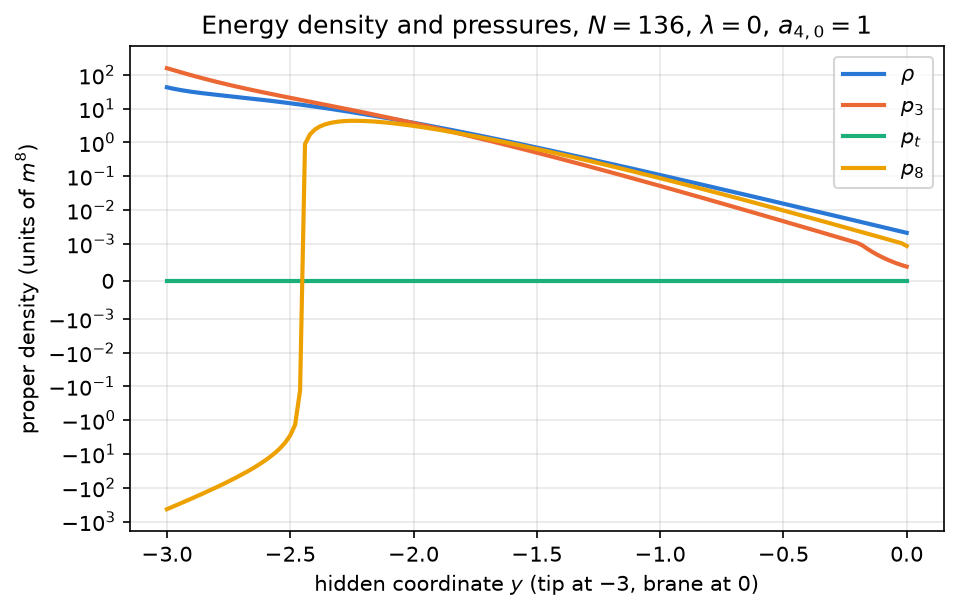

Figure 15b.1 saved as Revision/textbook/figures/15b_1_proper_emt.png
RESULT p_t without interaction: largest |p_t| = 0.0
PASS p_t = e_int = 0 when lambda = 0


In [4]:
prof = read_profile(RUN_FOLDER / "N136_lam0_a10.csv")
y = prof["y"]
step = float(y[1] - y[0])  # 0.02
COMPONENTS = [("rho", "$\\rho$"), ("p3", "$p_3$"), ("p_t", "$p_t$"), ("p8", "$p_8$")]
fig, ax = plt.subplots()
for colour, (column, label) in zip(PALETTE, COMPONENTS):
    ax.plot(y, prof[column], color=colour, lw=2.0, label=label)
ax.set_yscale("symlog", linthresh=1e-3)
ax.set_xlabel("hidden coordinate $y$ (tip at $-3$, brane at $0$)")
ax.set_ylabel("proper density (units of $m^8$)")
ax.set_title("Energy density and pressures, $N = 136$, $\\lambda = 0$, $a_{4,0} = 1$")
ax.legend()
save_figure(fig, "proper_emt",
            "The energy density $\\rho$ and the pressures $p_3$, $p_t$, $p_8$ of the "
            "Kohn-Sham state $N = 136$, $\\lambda = 0$, $a_{4,0} = 1$ as proper "
            "densities (vertical axis, symmetric logarithmic, units of $m^8$) "
            "against the hidden coordinate $y$ (horizontal axis). All are largest "
            "at the tip, where the proper volume is small; $p_8$ is negative near "
            "the tip and changes sign near $y = -2.45$, and $p_t$ is zero without "
            "interaction.")
report("p_t without interaction: largest |p_t|", float(np.max(np.abs(prof["p_t"]))))
check(float(np.max(np.abs(prof["p_t"]))) == 0.0, "p_t = e_int = 0 when lambda = 0")

## 7. What is integrated: the coordinate densities

Multiplying by $2\,\mathrm{Vol}_7\, e^{6Hy}$ turns a proper density into the amount
per unit of $y$ in the whole box of the doubled system. The next cell draws these
densities (now on a linear axis) and integrates them with Simpson's rule on the 151
points: the integral of the energy density must be the Kohn-Sham energy $E_{KS}$ of
the solver's JSON record (and of the committed table `ground/summary.csv`), and the
integrals of the pressures must agree with the committed table
`ground/emt-integrals.csv`. The solver integrates on a finer grid (1801 points), so
the comparison allows a relative difference of $10^{-6}$.

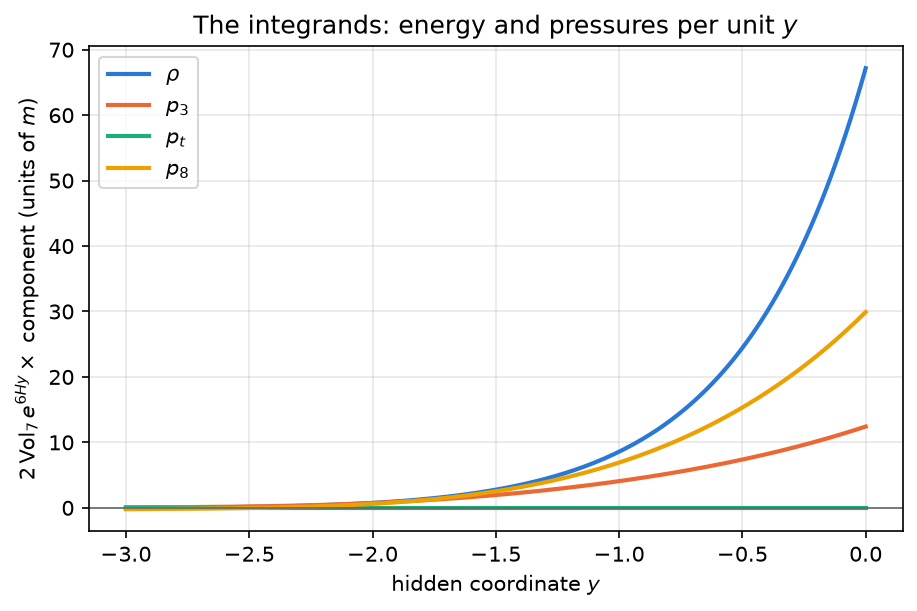

Figure 15b.2 saved as Revision/textbook/figures/15b_2_coordinate_emt.png
RESULT E_KS from the profile / from the solver = 32.38411614 / 32.38411569
RESULT largest relative difference of the integrals to the record = 1.4e-08
PASS the solver's E_KS equals the record
     reproduces Revision/kohn_sham/results/ground/summary.csv, N136_lam0_a10
PASS Simpson's rule on the profile gives E_KS and the recorded integrals
     reproduces Revision/kohn_sham/results/ground/emt-integrals.csv, columns int_rho,
    int_p3, int_p8


In [5]:
def simpson(values, h):
    """Simpson's rule on equally spaced points (an odd number of them)."""
    weights = np.full(len(values), 2.0)
    weights[1::2] = 4.0
    weights[0] = weights[-1] = 1.0
    return h / 3.0 * float(np.sum(weights * values))


def read_rows(relative):
    """The rows of a committed CSV table of the record as a dictionary by id."""
    with open(repository_file(relative), newline="", encoding="utf-8") as handle:
        return {row["id"]: row for row in csv.DictReader(handle)}


EMT_TABLE = "Revision/kohn_sham/results/ground/emt-integrals.csv"
emt_rows = read_rows(EMT_TABLE)
summary_rows = read_rows("Revision/kohn_sham/results/ground/summary.csv")
weight = 2.0 * VOL7 * np.exp(6.0 * H * y)  # 2 Vol_7 e^{6Hy}
fig, ax = plt.subplots()
integrals = {}
for colour, (column, label) in zip(PALETTE, COMPONENTS):
    ax.plot(y, weight * prof[column], color=colour, lw=2.0, label=label)
    integrals[column] = simpson(weight * prof[column], step)
ax.axhline(0.0, color="0.4", lw=0.8)
ax.set_xlabel("hidden coordinate $y$")
ax.set_ylabel("$2\\,\\mathrm{Vol}_7\\, e^{6Hy} \\times$ component (units of $m$)")
ax.set_title("The integrands: energy and pressures per unit $y$")
ax.legend()
save_figure(fig, "coordinate_emt",
            "The energy density and the pressures of the state $N = 136$, "
            "$\\lambda = 0$, $a_{4,0} = 1$ multiplied by $2\\,\\mathrm{Vol}_7 "
            "e^{6Hy}$ (vertical axis, linear, units of $m$ per unit $y$) against "
            "$y$ (horizontal axis). In this form the energy and the pressures sit "
            "near the brane; the area under $\\rho$ is the Kohn-Sham energy "
            "$E_{KS} = 32.384$.")
row = emt_rows["N136_lam0_a10"]
rel = lambda a, b: abs(a - b) / max(abs(b), 1e-300)
worst_int = max(rel(integrals[c], float(row[f"int_{c}"])) for c in ("rho", "p3", "p8"))
report("E_KS from the profile / from the solver",
       f"{integrals['rho']:.8f} / {free_state['E_KS']:.8f}")
report("largest relative difference of the integrals to the record", f"{worst_int:.1e}")
check(rel(free_state["E_KS"], float(summary_rows["N136_lam0_a10"]["E_KS"])) < 1e-12,
      "the solver's E_KS equals the record",
      record="Revision/kohn_sham/results/ground/summary.csv, N136_lam0_a10")
check(rel(integrals["rho"], free_state["E_KS"]) < 1e-6 and worst_int < 1e-6,
      "Simpson's rule on the profile gives E_KS and the recorded integrals",
      record=f"{EMT_TABLE}, columns int_rho, int_p3, int_p8")

## 8. The conservation law along the hidden direction

The next cell computes the left side $(e^{6Hy}p_8)'$ by the fourth-order finite
difference (one-sided fourth-order formulas at the two ends, as in the solver) and
the right side $3H e^{6Hy}(p_3 + p_t)$, draws both, and draws their difference
divided by the largest of the two sides. It also compares the jump
$[e^{6Hy}p_8]_{-3}^{0}$ with the integral of the right side. The solver checked the
same law on its fine grid (record checks `emt_y_conservation_pointwise` and
`emt_y_conservation_integrated`); on the 151 points of the profile the finite
difference is less accurate, so the tolerances here are $10^{-4}$ (point by point)
and $10^{-6}$ (integrated).

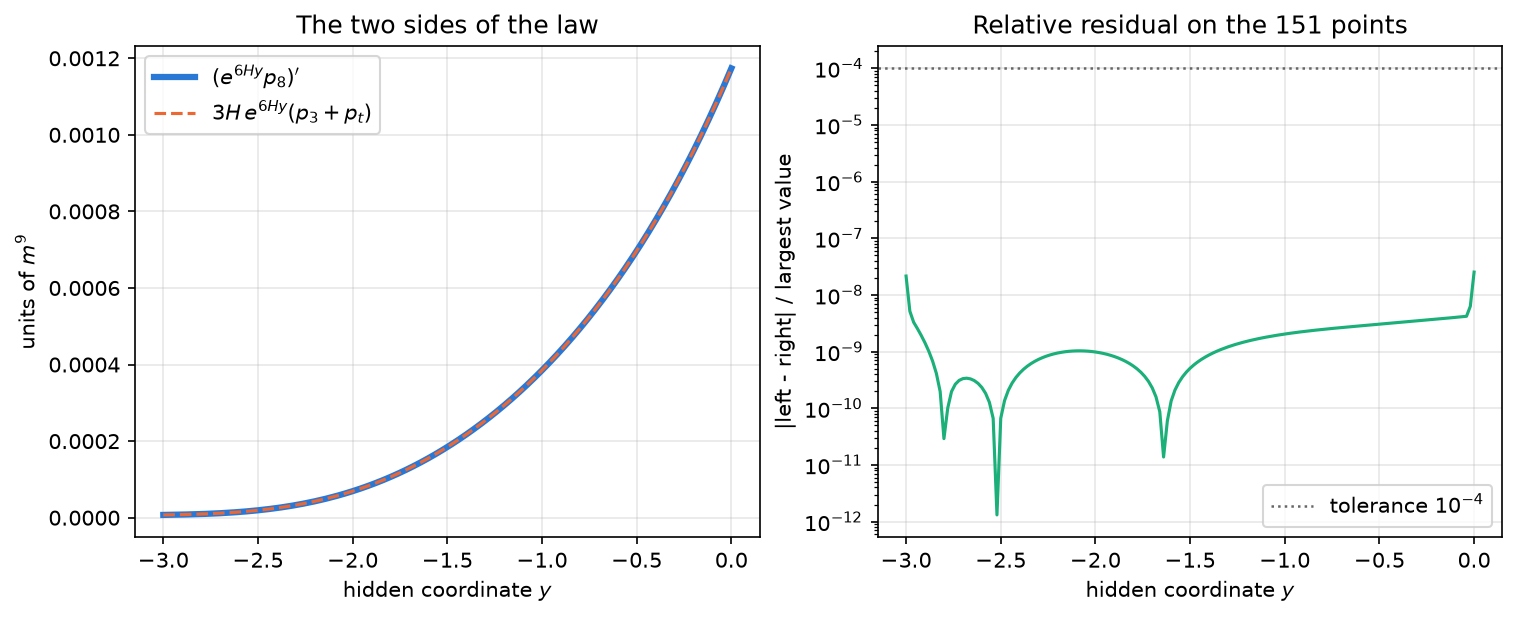

Figure 15b.3 saved as Revision/textbook/figures/15b_3_y_conservation.png
RESULT largest pointwise residual / integrated residual = 2.5e-08 / 6.1e-10
PASS (e^{6Hy} p8)' = 3H e^{6Hy} (p3 + p_t) holds for N136_lam0_a10
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, checks
    emt_y_conservation_pointwise and emt_y_conservation_integrated


In [6]:
def derivative4(f, h):
    """Fourth-order finite-difference derivative (one-sided at the two ends)."""
    d = np.zeros(len(f))
    d[2:-2] = (f[:-4] - 8.0 * f[1:-3] + 8.0 * f[3:-1] - f[4:]) / (12.0 * h)
    d[0] = (-25 * f[0] + 48 * f[1] - 36 * f[2] + 16 * f[3] - 3 * f[4]) / (12.0 * h)
    d[1] = (-3 * f[0] - 10 * f[1] + 18 * f[2] - 6 * f[3] + f[4]) / (12.0 * h)
    d[-1] = (25 * f[-1] - 48 * f[-2] + 36 * f[-3] - 16 * f[-4] + 3 * f[-5]) / (12.0 * h)
    d[-2] = (3 * f[-1] + 10 * f[-2] - 18 * f[-3] + 6 * f[-4] - f[-5]) / (12.0 * h)
    return d


def conservation(p):
    """(left side, right side, pointwise residual, integrated residual) of the law."""
    e6 = np.exp(6.0 * H * p["y"])
    left = derivative4(e6 * p["p8"], step)
    right = 3.0 * H * e6 * (p["p3"] + p["p_t"])
    scale = max(float(np.max(np.abs(left))), float(np.max(np.abs(right))))
    jump = e6[-1] * p["p8"][-1] - e6[0] * p["p8"][0]
    integral = simpson(right, step)
    return left, right, np.abs(left - right) / scale, abs(jump - integral) / abs(jump)


left, right, residual, integrated = conservation(prof)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
ax1.plot(y, left, color=PALETTE[0], lw=3.0, label="$(e^{6Hy}p_8)'$")
ax1.plot(y, right, color=PALETTE[1], lw=1.5, ls="--",
         label="$3H\\,e^{6Hy}(p_3 + p_t)$")
ax1.set_xlabel("hidden coordinate $y$")
ax1.set_ylabel("units of $m^9$")
ax1.set_title("The two sides of the law")
ax1.legend()
ax2.semilogy(y, np.maximum(residual, 1e-16), color=PALETTE[2], lw=1.5)
ax2.axhline(1e-4, color="0.4", ls=":", lw=1.2, label="tolerance $10^{-4}$")
ax2.set_xlabel("hidden coordinate $y$")
ax2.set_ylabel("|left - right| / largest value")
ax2.set_title("Relative residual on the 151 points")
ax2.legend()
save_figure(fig, "y_conservation",
            "Left: the two sides of the conservation law along the hidden "
            "direction, $(e^{6Hy}p_8)'$ (solid) and $3H e^{6Hy}(p_3 + p_t)$ "
            "(dashed), for $N = 136$, $\\lambda = 0$, $a_{4,0} = 1$ (vertical axis, "
            "units of $m^9$; horizontal axis $y$); the curves lie on top of each "
            "other. Right: their difference relative to the largest value "
            "(logarithmic), the error of the finite difference on the coarse "
            "profile grid, far below the tolerance.")
report("largest pointwise residual / integrated residual",
       f"{float(np.max(residual)):.1e} / {integrated:.1e}")
check(float(np.max(residual)) < 1e-4 and integrated < 1e-6,
      "(e^{6Hy} p8)' = 3H e^{6Hy} (p3 + p_t) holds for N136_lam0_a10",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, checks "
             "emt_y_conservation_pointwise and emt_y_conservation_integrated")

## 9. The energy along the history and its slope

The next cell solves the state $N = 136$ without interaction at 17 slices,
$a_{4,0} = 0, 0.125, 0.25, \dots, 2$ (about a third of a second each), and reads
from each JSON record the energy $E_{KS}$ and the integrals
$2\,\mathrm{Vol}_7\int e^{6Hy}(\cdot)\,dy$ of $\rho$, $p_3$, $p_t$, $p_8$ that the
solver computed on its fine grid. From them it forms the slope
$-3(\int p_3 - \int p_t)$ of the energy-change identity. At the five slices of the
canonical matrix the energies and integrals must equal the committed tables, and
the slopes must equal the derivative $dE/da_4$ that the solver obtained by
finite differences between neighbouring slices (column `dE_da4_finite_difference`
of `adiabatic/adiabaticity.csv`).

In [7]:
DENSE = [i / 8.0 for i in range(17)]  # the slices 0, 0.125, ..., 2
history = []
for a4 in DENSE:
    record = solve_state(f"N136_lam0_dense_{round(1000 * a4):04d}", 136, 0.0, a4)
    ints = record["emtIntegrals_2Vol7_int_e6Hy"]  # 2 Vol_7 int e^{6Hy} (...) dy
    history.append({"a4": a4, "E": record["E_KS"], "rho": ints["rho"],
                    "p3": ints["p3"], "p_t": ints["p_t"], "p8": ints["p8"],
                    "slope": -3.0 * (ints["p3"] - ints["p_t"])})
adiabatic_rows = read_rows("Revision/kohn_sham/results/adiabatic/adiabaticity.csv")
worst_e, worst_slope = 0.0, 0.0
say("a4,0       E_KS     dE/da4 (EMT)   dE/da4 (record, finite differences)")
for item in history:
    if item["a4"] in (0.0, 0.5, 1.0, 1.5, 2.0):
        key = f"N136_lam0_a{round(10 * item['a4']):02d}"
        recorded_slope = float(adiabatic_rows[key]["dE_da4_finite_difference"])
        worst_e = max(worst_e, rel(item["E"], float(summary_rows[key]["E_KS"])),
                      rel(item["p3"], float(emt_rows[key]["int_p3"])))
        worst_slope = max(worst_slope, rel(item["slope"], recorded_slope))
        say(f"{item['a4']:4.2f}  {item['E']:10.5f}  {item['slope']:12.6f}"
            f"  {recorded_slope:12.6f}")
report("largest relative difference of E and int p3 to the record", f"{worst_e:.1e}")
report("largest relative difference of the slopes", f"{worst_slope:.1e}")
check(worst_e < 1e-12, "E_KS and the integrals at the five slices equal the record",
      record="Revision/kohn_sham/results/ground/summary.csv and emt-integrals.csv")
check(worst_slope < 1e-8, "dE/da4 = -3 (int p3 - int p_t) at the five slices",
      record="Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column "
             "dE_da4_finite_difference")

a4,0       E_KS     dE/da4 (EMT)   dE/da4 (record, finite differences)
0.00    80.28222    -71.439756    -71.439756
0.50    51.24519    -46.470842    -46.470842
1.00    32.38412    -30.119224    -30.119224
1.50    20.20308    -19.339665    -19.339665
2.00    12.44507    -12.186143    -12.186143
RESULT largest relative difference of E and int p3 to the record = 0.0e+00
RESULT largest relative difference of the slopes = 3.7e-12
PASS E_KS and the integrals at the five slices equal the record
     reproduces Revision/kohn_sham/results/ground/summary.csv and emt-integrals.csv
PASS dE/da4 = -3 (int p3 - int p_t) at the five slices
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column
    dE_da4_finite_difference


The identity also holds between the slices. The next cell integrates the slopes over
the whole history with Simpson's rule on the 17 slices (step $0.125$) and compares
the result with the change of the energy itself, $E(2) - E(0)$: the energy lost by
the gas along the history is exactly the work done by the pressure difference. The
figure shows $E_{KS}$ at the 17 slices with short tangent lines whose slopes are
computed from the pressures alone.

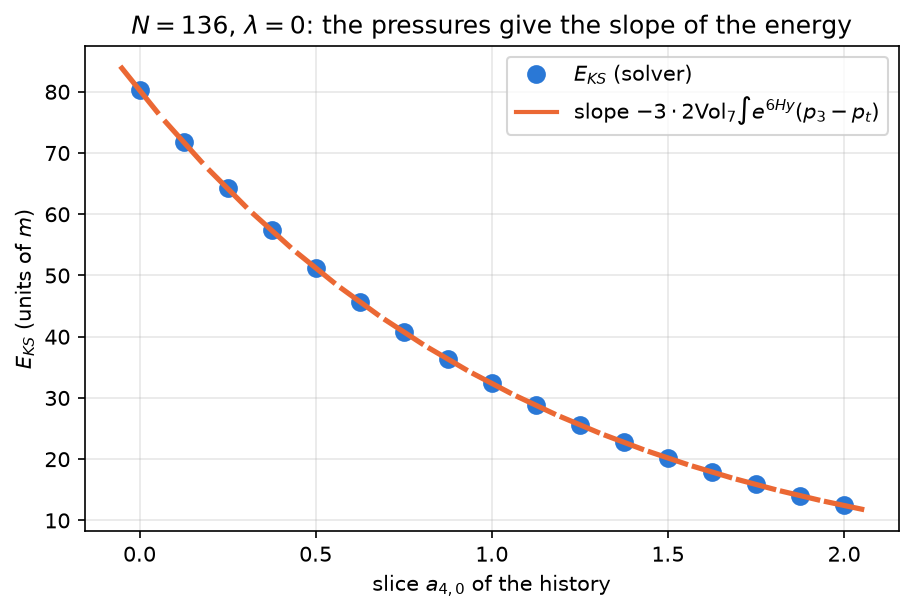

Figure 15b.4 saved as Revision/textbook/figures/15b_4_energy_slopes.png
RESULT E(2) - E(0) / integral of the slopes = -67.837152 / -67.837207
PASS the integrated slope equals E(2) - E(0) within 1e-5 (relative)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    emt_energy_change_dE_da4


In [8]:
slopes = np.array([item["slope"] for item in history])
energies = np.array([item["E"] for item in history])
work = simpson(slopes, 0.125)  # integral of dE/da4 over the history
change = energies[-1] - energies[0]
fig, ax = plt.subplots()
ax.plot(DENSE, energies, "o", color=PALETTE[0], ms=8, label="$E_{KS}$ (solver)")
for a4, e, s in zip(DENSE, energies, slopes):
    ax.plot([a4 - 0.05, a4 + 0.05], [e - 0.05 * s, e + 0.05 * s], color=PALETTE[1],
            lw=2.5)
ax.plot([], [], color=PALETTE[1], lw=2.0,
        label="slope $-3 \\cdot 2\\mathrm{Vol}_7 \\int e^{6Hy}(p_3 - p_t)$")
ax.set_xlabel("slice $a_{4,0}$ of the history")
ax.set_ylabel("$E_{KS}$ (units of $m$)")
ax.set_title("$N = 136$, $\\lambda = 0$: the pressures give the slope of the energy")
ax.legend()
save_figure(fig, "energy_slopes",
            "The Kohn-Sham energy $E_{KS}$ of $N = 136$ without interaction "
            "(vertical axis, units of $m$) at 17 slices $a_{4,0}$ of the history "
            "(horizontal axis), with short tangent lines whose slopes are computed "
            "from the pressures alone, $dE/da_4 = -3 \\cdot 2\\,\\mathrm{Vol}_7 "
            "\\int e^{6Hy}(p_3 - p_t)\\,dy$: every line touches the curve of the "
            "energies, which falls from $80.3$ to $12.4$.")
report("E(2) - E(0) / integral of the slopes", f"{change:.6f} / {work:.6f}")
check(rel(work, change) < 1e-5,
      "the integrated slope equals E(2) - E(0) within 1e-5 (relative)",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "emt_energy_change_dE_da4")

## 10. The integrated pressures along the history

The next cell divides the integrated pressures by the integrated energy density.
These ratios are the integrated components only: what a 3-space observer would call
an equation of state is not computed here (it needs the averaging over the hidden
direction and the extra times, which is the subject of the Revision dark-sector
work), and the history is a prescribed background. The figure shows
$\int p_3/\int\rho$ and $\int p_8/\int\rho$ for $N = 136$ at the 17 slices (lines)
and for $N = 136$ and $N = 688$ at the five slices of the record (markers). The check
compares the ratios of $N = 136$ at the five slices with the committed table.

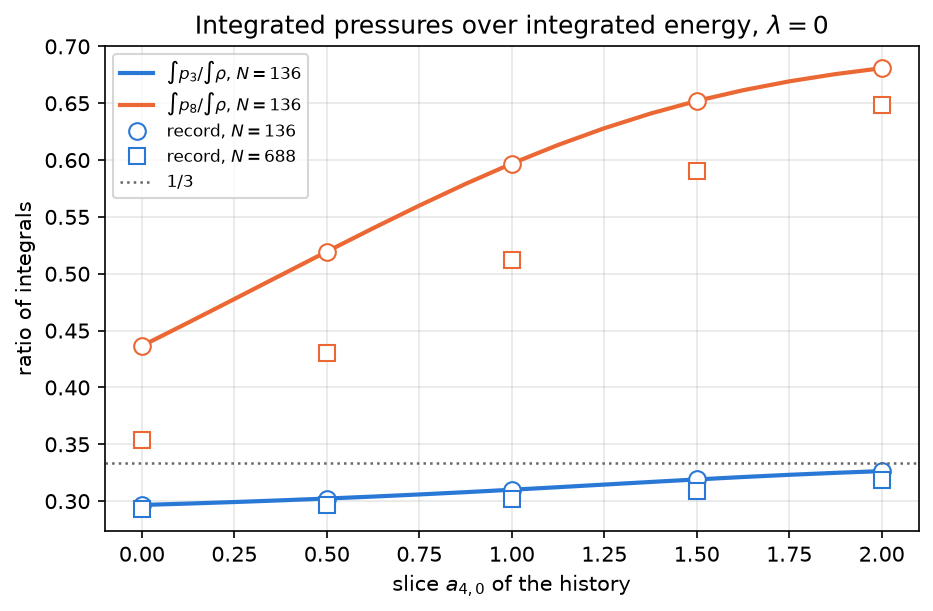

Figure 15b.5 saved as Revision/textbook/figures/15b_5_integrated_ratios.png
RESULT int p3 / int rho of N = 136 at a4,0 = 0, 1, 2 = 0.2966, 0.3100, 0.3264
RESULT int p8 / int rho of N = 136 at a4,0 = 0, 1, 2 = 0.4365, 0.5969, 0.6808
PASS the ratios at the five slices equal the record
     reproduces Revision/kohn_sham/results/ground/emt-integrals.csv, int_p3 / int_rho
PASS int p3 / int rho rises along the history and stays below 1/3


In [9]:
ratio3 = np.array([item["p3"] / item["rho"] for item in history])
ratio8 = np.array([item["p8"] / item["rho"] for item in history])
fig, ax = plt.subplots()
ax.plot(DENSE, ratio3, color=PALETTE[0], lw=2.0,
        label="$\\int p_3 / \\int \\rho$, $N = 136$")
ax.plot(DENSE, ratio8, color=PALETTE[1], lw=2.0,
        label="$\\int p_8 / \\int \\rho$, $N = 136$")
worst_ratio = 0.0
for marker, n in (("o", 136), ("s", 688)):
    keys = [f"N{n}_lam0_a{round(10 * a):02d}" for a in (0.0, 0.5, 1.0, 1.5, 2.0)]
    r3 = [float(emt_rows[k]["int_p3"]) / float(emt_rows[k]["int_rho"]) for k in keys]
    r8 = [float(emt_rows[k]["int_p8"]) / float(emt_rows[k]["int_rho"]) for k in keys]
    ax.plot([0, 0.5, 1, 1.5, 2], r3, marker, color=PALETTE[0], ms=8,
            markerfacecolor="white", label=f"record, $N = {n}$")
    ax.plot([0, 0.5, 1, 1.5, 2], r8, marker, color=PALETTE[1], ms=8,
            markerfacecolor="white")
    if n == 136:
        worst_ratio = max(abs(r3[i] - ratio3[4 * i]) for i in range(5))
ax.axhline(1.0 / 3.0, color="0.4", ls=":", lw=1.2, label="$1/3$")
ax.set_xlabel("slice $a_{4,0}$ of the history")
ax.set_ylabel("ratio of integrals")
ax.set_title("Integrated pressures over integrated energy, $\\lambda = 0$")
ax.legend(fontsize=8)
save_figure(fig, "integrated_ratios",
            "The integrated 3-space pressure (blue) and hidden-direction pressure "
            "(orange), each divided by the integrated energy density (vertical "
            "axis, pure numbers), against the slice $a_{4,0}$ (horizontal axis), for "
            "$N = 136$ without interaction at 17 slices (lines) and for $N = 136$ "
            "(circles) and $N = 688$ (squares) from the record. The 3-space ratio "
            "rises from about $0.30$ toward the value $1/3$ of a gas of massless "
            "particles as the momenta redshift. These are integrated components "
            "on a prescribed background, not an observed equation of state.")
report("int p3 / int rho of N = 136 at a4,0 = 0, 1, 2",
       ", ".join(f"{ratio3[i]:.4f}" for i in (0, 8, 16)))
report("int p8 / int rho of N = 136 at a4,0 = 0, 1, 2",
       ", ".join(f"{ratio8[i]:.4f}" for i in (0, 8, 16)))
check(worst_ratio < 1e-12, "the ratios at the five slices equal the record",
      record=f"{EMT_TABLE}, int_p3 / int_rho")
check(bool(np.all(np.diff(ratio3) > 0.0)) and ratio3[-1] < 1.0 / 3.0,
      "int p3 / int rho rises along the history and stays below 1/3")

## 11. Where the energy sits along the history

The next cell reads the committed profiles of $N = 136$, $\lambda = 0$ at the five
slices and draws the coordinate energy density divided by the total energy,
$2\,\mathrm{Vol}_7 e^{6Hy}\rho(y)/E_{KS}$, whose area is 1. As the brane band
redshifts, its orbitals reach further from the brane toward the tip. The check
measures this with the mean position $\langle y \rangle = \int y \cdot (\text{this
density})\,dy$, which must decrease from slice to slice.

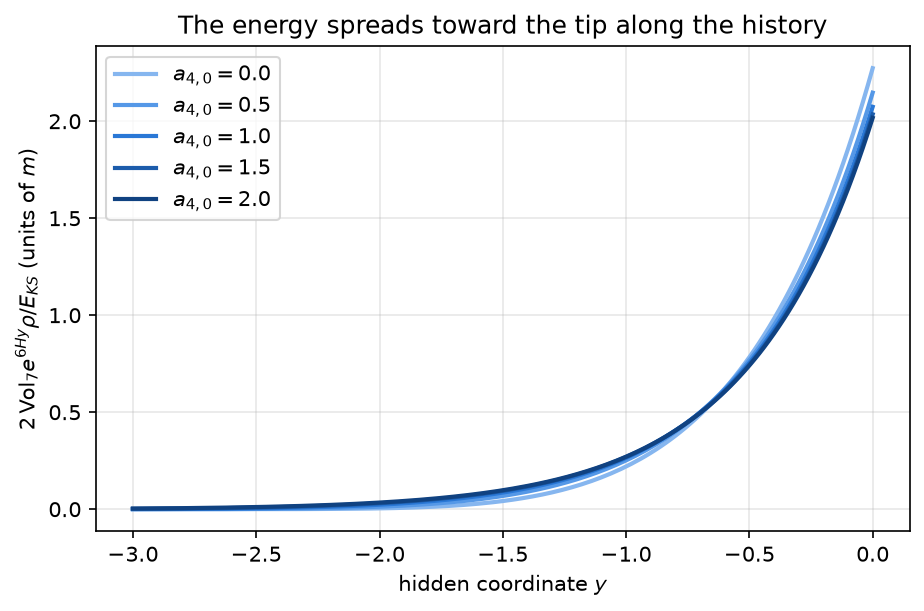

Figure 15b.6 saved as Revision/textbook/figures/15b_6_energy_spreading.png
RESULT mean position <y> of the energy at the five slices = -0.3873, -0.4263, -0.4556,
    -0.4746, -0.4849
PASS the mean position of the energy moves toward the tip from slice to slice


In [10]:
fig, ax = plt.subplots()
means = []
for shade, a4 in zip(SLICE_SHADES, (0.0, 0.5, 1.0, 1.5, 2.0)):
    p = read_profile(repository_file(f"{RECORD_PROFILES}/N136_lam0_a"
                                     f"{round(10 * a4):02d}.csv"))
    density = 2.0 * VOL7 * np.exp(6.0 * H * p["y"]) * p["rho"]
    density = density / simpson(density, step)  # area 1
    means.append(simpson(p["y"] * density, step))
    ax.plot(p["y"], density, color=shade, lw=2.0, label=f"$a_{{4,0}} = {a4}$")
ax.set_xlabel("hidden coordinate $y$")
ax.set_ylabel("$2\\,\\mathrm{Vol}_7 e^{6Hy}\\rho / E_{KS}$ (units of $m$)")
ax.set_title("The energy spreads toward the tip along the history")
ax.legend()
save_figure(fig, "energy_spreading",
            "The energy per unit $y$ divided by the total energy, "
            "$2\\,\\mathrm{Vol}_7 e^{6Hy}\\rho(y)/E_{KS}$ (vertical axis, area 1), "
            "of $N = 136$ without interaction at the five slices $a_{4,0} = 0$ to "
            "$2$ (light to dark blue), against $y$ (horizontal axis). The energy is "
            "concentrated near the brane, and its distribution moves toward the tip "
            "as the history proceeds.")
report("mean position <y> of the energy at the five slices",
       ", ".join(f"{m:.4f}" for m in means))
check(all(means[i + 1] < means[i] for i in range(4)),
      "the mean position of the energy moves toward the tip from slice to slice")

## 12. The interaction terms

With interaction the energy density $e_{int}$ enters every component: it is
subtracted in $\rho$ and added to $p_3$, $p_8$ and, alone, forms $p_t$. The next
cell uses the strongly interacting state $N = 136$, $+\lambda_2$, $a_{4,0} = 2$: it
draws $e_{int}$ and its two parts $\tfrac{15}{32}\lambda S^2$ and
$-\tfrac{1}{32}\lambda n^2$ (computed here from the profile columns $S$ and $n$),
checks that the column $e_{int}$ of the profile is this sum and that $p_t = e_{int}$
exactly, and checks the conservation law for this state too (where $p_t \ne 0$).
Finally it counts, among the 60 interacting ground states of the committed table
`ground/emt-integrals.csv`, how many have a positive and how many a negative
integrated extra-time pressure $2\,\mathrm{Vol}_7\int e^{6Hy}p_t\,dy$: both signs
occur, so the deflation of the extra times can give energy to the gas or take
energy from it.

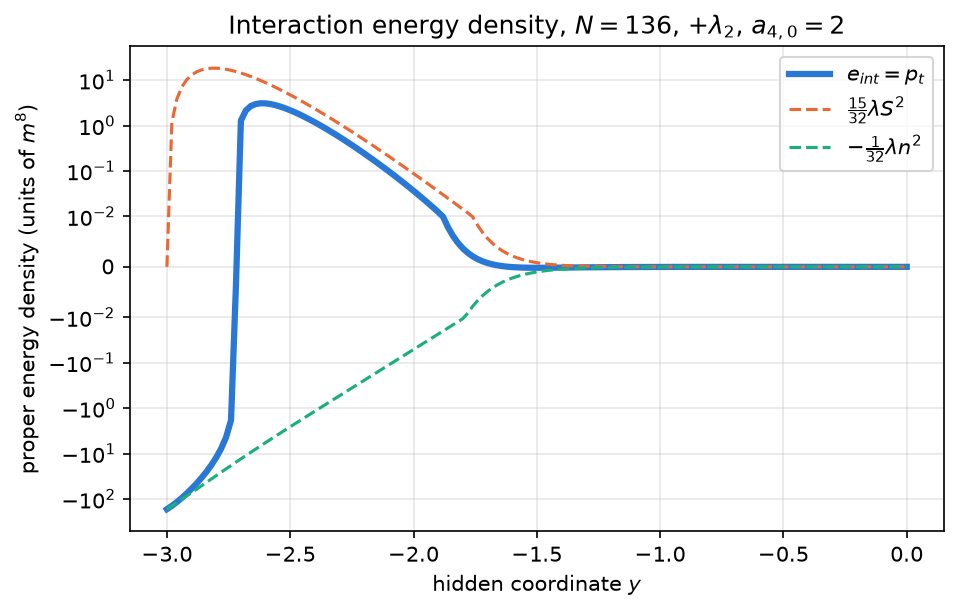

Figure 15b.7 saved as Revision/textbook/figures/15b_7_interaction_terms.png
RESULT largest |e_int - (15/32 lambda S^2 - 1/32 lambda n^2)| / max|e_int| = 6.8e-16
RESULT conservation law with interaction: pointwise / integrated residual = 5.0e-06 /
    2.3e-08
PASS e_int = lambda (15/32 S^2 - 1/32 n^2) and p_t = e_int
PASS the conservation law holds for the interacting state N136_lamp2_a20
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, checks
    emt_y_conservation_pointwise and emt_y_conservation_integrated
RESULT interacting states with integrated p_t > 0 / < 0 = 29 / 31
PASS the integrated extra-time pressure takes both signs
     reproduces Revision/kohn_sham/results/ground/emt-integrals.csv, column int_p_t


In [11]:
sp = read_profile(RUN_FOLDER / "N136_lamp2_a20.csv")
hartree = LAMBDA2_136 * 15.0 / 32.0 * sp["S"] ** 2  # (15/32) lambda S^2
exchange = -LAMBDA2_136 / 32.0 * sp["n"] ** 2  # -(1/32) lambda n^2
fig, ax = plt.subplots()
ax.plot(sp["y"], sp["e_int"], color=PALETTE[0], lw=3.0, label="$e_{int} = p_t$")
ax.plot(sp["y"], hartree, color=PALETTE[1], lw=1.5, ls="--",
        label="$\\frac{15}{32}\\lambda S^2$")
ax.plot(sp["y"], exchange, color=PALETTE[2], lw=1.5, ls="--",
        label="$-\\frac{1}{32}\\lambda n^2$")
ax.set_yscale("symlog", linthresh=1e-2)
ax.set_xlabel("hidden coordinate $y$")
ax.set_ylabel("proper energy density (units of $m^8$)")
ax.set_title("Interaction energy density, $N = 136$, $+\\lambda_2$, $a_{4,0} = 2$")
ax.legend()
save_figure(fig, "interaction_terms",
            "The interaction energy density $e_{int}$, which is also the extra-time "
            "pressure $p_t$ (solid), and its two parts, the positive term "
            "$\\frac{15}{32}\\lambda S^2$ and the negative term "
            "$-\\frac{1}{32}\\lambda n^2$ (dashed), for $N = 136$ with the "
            "repulsive coupling $+\\lambda_2$ at $a_{4,0} = 2$ (vertical axis, "
            "symmetric logarithmic, proper units $m^8$; horizontal axis $y$). The "
            "interaction lives near the tip, where the proper densities are large.")
sum_error = float(np.max(np.abs(hartree + exchange - sp["e_int"]))) / float(
    np.max(np.abs(sp["e_int"])))
_, _, residual2, integrated2 = conservation(sp)
report("largest |e_int - (15/32 lambda S^2 - 1/32 lambda n^2)| / max|e_int|",
       f"{sum_error:.1e}")
report("conservation law with interaction: pointwise / integrated residual",
       f"{float(np.max(residual2)):.1e} / {integrated2:.1e}")
check(sum_error < 1e-12 and bool(np.all(sp["p_t"] == sp["e_int"])),
      "e_int = lambda (15/32 S^2 - 1/32 n^2) and p_t = e_int")
check(float(np.max(residual2)) < 1e-4 and integrated2 < 1e-6,
      "the conservation law holds for the interacting state N136_lamp2_a20",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, checks "
             "emt_y_conservation_pointwise and emt_y_conservation_integrated")
int_pt = [float(row["int_p_t"]) for key, row in emt_rows.items()
          if "_lam0_" not in key]  # the 60 interacting ground states
positive = sum(1 for value in int_pt if value > 0.0)
negative = sum(1 for value in int_pt if value < 0.0)
report("interacting states with integrated p_t > 0 / < 0", f"{positive} / {negative}")
check(len(int_pt) == 60 and positive > 0 and negative > 0,
      "the integrated extra-time pressure takes both signs",
      record=f"{EMT_TABLE}, column int_p_t")

## 13. Why this tensor cannot drive the history

The field equations for $a_4$ (the Einstein-Lovelock equations of the author's
metric) accept a source only under three conditions (Revision record
Revision/field_equations_a4/reports/ks-source-conditions.json, key `conditions`):

- (C1) every component of the source is independent of $x_8$, that is, of $y$;
- (C2) $p_3 + p_t = 2 p_8$ at every point;
- (C3) for the linear history $a_4 = AHx_4 + a_0$ used here: $p_3 = p_t = p_8$
  and a constant $\rho$.

The next cell tests the three conditions on this notebook's own numbers: the
profile of $N = 136$, $\lambda = 0$, $a_{4,0} = 1$ for C1 and C2 point by point,
and the 17 slices of the history for C2 after the integration over $y$ and for C3.
It prints the profile at $y = -3, -1.5, 0$ and checks these values and the
integrated ratios $(\int p_3 + \int p_t)/(2\int p_8)$ at $a_{4,0} = 0, 1, 2$
against the numbers printed in the record's checks (6 significant digits). All
three conditions fail, as the record says: the Kohn-Sham gas is a test field on a
PRESCRIBED BACKGROUND, not a source that would produce the deflating history.

In [12]:
import re  # finds the numbers inside the record's text

SOURCE = "Revision/field_equations_a4/reports/ks-source-conditions.json"
source = json.loads(repository_file(SOURCE).read_text(encoding="utf-8"))
details = {item["name"]: item["detail"] for item in source["checks"]}
t_scale = max(float(np.max(np.abs(prof[c]))) for c in ("rho", "p3", "p_t", "p8"))
c1 = (float(np.max(prof["rho"])) - float(np.min(prof["rho"]))) / t_scale  # C1 test
c2 = prof["p3"] + prof["p_t"] - 2.0 * prof["p8"]  # zero everywhere if C2 held
number = r"(-?[0-9.]+(?:e[-+]?[0-9]+)?)"  # a number as the record prints it
examples = re.findall(
    rf"y = {number}: rho = {number}, p3 = {number}, p_t = {number}, "
    rf"p8 = {number}, p3 \+ p_t - 2 p8 = {number}",
    details["ks_profiles_violate_algebraic_condition"])
say("    y         rho          p3      p_t          p8  p3 + p_t - 2 p8")
worst_example = 0.0
for example in examples:
    y0, values = float(example[0]), [float(v) for v in example[1:]]
    i = int(np.argmin(np.abs(y - y0)))  # the profile point at this y
    mine = [float(prof["rho"][i]), float(prof["p3"][i]), float(prof["p_t"][i]),
            float(prof["p8"][i]), float(c2[i])]
    say(f"{y[i] + 0.0:5.1f}  {mine[0]:10.6g}  {mine[1]:10.6g}"  # + 0.0 turns -0 into 0
        f"  {mine[2] + 0.0:7.3g}  {mine[3]:10.6g}  {mine[4]:15.6g}")
    for a, b in zip(mine, values):  # 6 significant digits: relative 5e-6
        worst_example = max(worst_example, abs(a - b) / max(abs(b), 1e-300)
                            if b != 0.0 else abs(a))
ratios_c2 = {item["a4"]: (item["p3"] + item["p_t"]) / (2.0 * item["p8"])
             for item in history}
recorded_c2 = {int(key[-2:]) / 10.0: float(value) for key, value in re.findall(
    r"(N136_lam0_a[0-9][0-9]): ([0-9.]+)",
    details["ks_integrals_violate_algebraic_condition"])}
worst_c2 = max(abs(ratios_c2[a4] / value - 1.0) for a4, value in recorded_c2.items())
report("C1: (max rho - min rho) / max|T| for N136_lam0_a10", f"{c1:.4f}")
report("C2 integrated: (int p3 + int p_t)/(2 int p8) at a4,0 = 0, 1, 2",
       ", ".join(f"{ratios_c2[a]:.6f}" for a in (0.0, 1.0, 2.0)))
report("C3: int rho at a4,0 = 0 and 2; int p3 and int p_t at a4,0 = 1",
       f"{history[0]['rho']:.4f}, {history[-1]['rho']:.4f}; "
       f"{history[8]['p3']:.4f}, {history[8]['p_t']:.1f}")
check(c1 > 0.01 and len(examples) == 3 and worst_example < 5e-6
      and float(np.min(np.abs(c2[[0, len(c2) // 2, -1]]))) > 0.0,
      "C1 and C2 fail for N136_lam0_a10; the record's example values reproduced",
      record=f"{SOURCE}, checks ks_profiles_depend_on_x8 and "
             "ks_profiles_violate_algebraic_condition")
check(len(recorded_c2) == 3 and worst_c2 < 5e-6
      and all(abs(r - 1.0) > 0.5 for r in ratios_c2.values()),
      "C2 fails after integration at all 17 slices; the record's ratios reproduced",
      record=f"{SOURCE}, check ks_integrals_violate_algebraic_condition")
check(history[-1]["rho"] < 0.2 * history[0]["rho"]
      and all(item["p3"] > 0.25 * item["rho"] and item["p_t"] == 0.0
              for item in history),
      "C3 fails: rho changes along the history and p3 differs from p_t",
      record=f"{SOURCE}, check ks_history_is_a_prescribed_background")

    y         rho          p3      p_t          p8  p3 + p_t - 2 p8
 -3.0     43.0702     158.268        0    -431.733          1021.73
 -1.5    0.707818    0.498835        0    0.643324        -0.787813
  0.0  0.00211576  0.000391237        0  0.000942049      -0.00149286
RESULT C1: (max rho - min rho) / max|T| for N136_lam0_a10 = 0.0998
RESULT C2 integrated: (int p3 + int p_t)/(2 int p8) at a4,0 = 0, 1, 2 = 0.339767,
    0.259690, 0.239714
RESULT C3: int rho at a4,0 = 0 and 2; int p3 and int p_t at a4,0 = 1 = 80.2822, 12.4451;
    10.0397, 0.0
PASS C1 and C2 fail for N136_lam0_a10; the record's example values reproduced
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, checks
    ks_profiles_depend_on_x8 and ks_profiles_violate_algebraic_condition
PASS C2 fails after integration at all 17 slices; the record's ratios reproduced
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_integrals_violate_algebraic_condition


## 14. The last check

The last cell checks that every figure file of this notebook exists and prints the
number of checks that passed.

In [13]:
NAMES = ["proper_emt", "coordinate_emt", "y_conservation", "energy_slopes",
         "integrated_ratios", "energy_spreading", "interaction_terms"]
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/15b_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 18 CHECKS PASSED (notebook 15b)


## 15. What this notebook showed

- The solver's profiles of the energy density and the three pressures are
  reproduced on this computer, and their integrals give the Kohn-Sham energy
  (COMPUTED).
- The conservation law along the hidden direction,
  $(e^{6Hy}p_8)' = 3H e^{6Hy}(p_3 + p_t)$, holds point by point and integrated, with
  and without interaction (an exact identity, checked numerically).
- Along the deflating history the energy of the gas changes exactly by the work of
  the pressure difference, $dE/da_4 = -3 \cdot 2\,\mathrm{Vol}_7\int e^{6Hy}(p_3 -
  p_t)\,dy$: the 3-space pressure takes energy from the gas as 3-space inflates,
  and the extra-time pressure, which is only the interaction energy density (zero
  without interaction, of either sign with it), adds or removes a small amount as
  the extra times deflate.
- The integrated ratio $\int p_3/\int\rho$ rises toward $1/3$ as the momenta
  redshift; the energy moves toward the tip.
- The history is PRESCRIBED: these components are not an admissible source of the
  equations for $a_4$ (they depend on $y$, $p_3 + p_t \ne 2p_8$, and along the
  history $\rho$ changes and $p_3 \ne p_t$; checked here on the notebook's own
  numbers), and no equation of state seen by an observer is claimed here.